# Day 2 — Joint PINN K-sweep on 7 clean CALB cells

**What changed from Day 1:**
- One model trained JOINTLY on all 7 cells (not per-cell)
- Learnable per-cell `k_SEI` (initialised from linear fit on K-window)
- Learnable per-cell exponent `p` (Ramadass form: `dSoH/dn = -k_SEI · SoH^p`)
- Cell-embedding latent code (dim 4) so the model can distinguish cells

**Question:** does the joint architecture with real ODE physics beat pure physics across the K sweep?

In [1]:
import sys, pickle
sys.path.insert(0, '/home/hj/Desktop/PINNs')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('/home/hj/Desktop/PINNs/Voltaris/outputs/sciml_day2')
df = pd.read_csv(OUT / 'ksweep_summary.csv')
with open(OUT / 'ksweep_trajectories.pkl', 'rb') as f:
    trajectories = pickle.load(f)
K_VALUES = sorted(df.K_train_cy.unique().tolist())

/home/hj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Headline table — median RMSE and cells-under-3pp per K

In [2]:
rows = []
for K in K_VALUES:
    k = df[df.K_train_cy == K]
    rows.append({
        'K': K,
        'PINN median [pp]': round(k.rmse_pinn_test_pp.median(), 2),
        'phys median [pp]': round(k.rmse_phys_test_pp.median(), 2),
        'PINN max [pp]':    round(k.rmse_pinn_test_pp.max(), 2),
        'phys max [pp]':    round(k.rmse_phys_test_pp.max(), 2),
        'PINN <3pp':        f"{int((k.rmse_pinn_test_pp<3.0).sum())}/7",
        'phys <3pp':        f"{int((k.rmse_phys_test_pp<3.0).sum())}/7",
        'PINN wins':        f"{int((k.rmse_pinn_test_pp<k.rmse_phys_test_pp).sum())}/7",
    })
pd.DataFrame(rows)

,K,PINN median [pp],phys median [pp],PINN max [pp],phys max [pp],PINN <3pp,phys <3pp,PINN wins
0,50,4.51,19.97,7.63,37.50,2/7,1/7,6/7
1,100,2.55,1.02,4.38,7.32,6/7,5/7,2/7
2,200,2.94,1.62,6.22,5.68,4/7,5/7,2/7
3,400,5.21,1.43,10.12,2.36,1/7,7/7,0/7


## 2. Per-cell breakdown across K

In [3]:
piv_pinn = df.pivot(index='cell_id', columns='K_train_cy', values='rmse_pinn_test_pp').round(2)
piv_pinn.columns = [f'PINN K={c}' for c in piv_pinn.columns]
piv_phys = df.pivot(index='cell_id', columns='K_train_cy', values='rmse_phys_test_pp').round(2)
piv_phys.columns = [f'phys K={c}' for c in piv_phys.columns]
pd.concat([piv_pinn, piv_phys], axis=1)

,PINN K=50,PINN K=100,PINN K=200,PINN K=400,phys K=50,phys K=100,phys K=200,phys K=400
cell_id,,,,,,,,
6,2.61,2.64,1.24,10.12,19.97,4.86,4.17,1.07
7,4.94,2.58,3.44,10.12,37.50,7.32,5.68,1.45
10,3.01,2.55,1.53,5.21,4.69,0.99,0.42,0.51
14,4.99,2.43,3.38,8.44,34.71,1.02,1.34,1.43
19,7.63,4.38,6.22,1.88,33.24,1.75,2.09,1.54
20,4.51,2.05,2.94,3.81,5.16,0.30,1.62,2.36
25,2.26,2.41,1.34,4.58,1.38,0.31,0.44,0.89


## 3. RMSE vs K — PINN vs physics

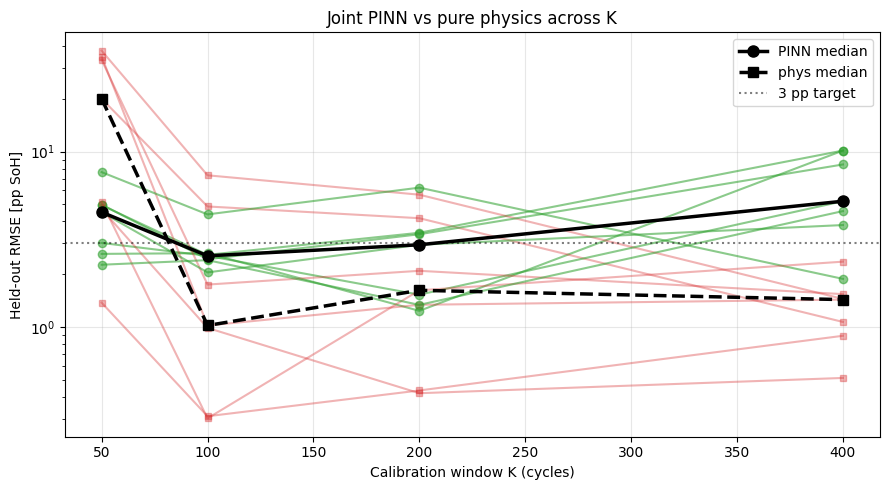

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for cid, g in df.groupby('cell_id'):
    ax.plot(g.K_train_cy, g.rmse_pinn_test_pp, 'o-', alpha=0.55,
            color='tab:green', markersize=6)
    ax.plot(g.K_train_cy, g.rmse_phys_test_pp, 's-', alpha=0.35,
            color='tab:red', markersize=5)
med_pinn = df.groupby('K_train_cy').rmse_pinn_test_pp.median()
med_phys = df.groupby('K_train_cy').rmse_phys_test_pp.median()
ax.plot(med_pinn.index, med_pinn.values, 'k-o', lw=2.5, label='PINN median', markersize=8)
ax.plot(med_phys.index, med_phys.values, 'k--s', lw=2.5, label='phys median', markersize=7)
ax.axhline(3, color='k', ls=':', alpha=0.5, label='3 pp target')
ax.set_xlabel('Calibration window K (cycles)')
ax.set_ylabel('Held-out RMSE [pp SoH]')
ax.set_title('Joint PINN vs pure physics across K')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Trajectory grid at K=100 — the sweet spot

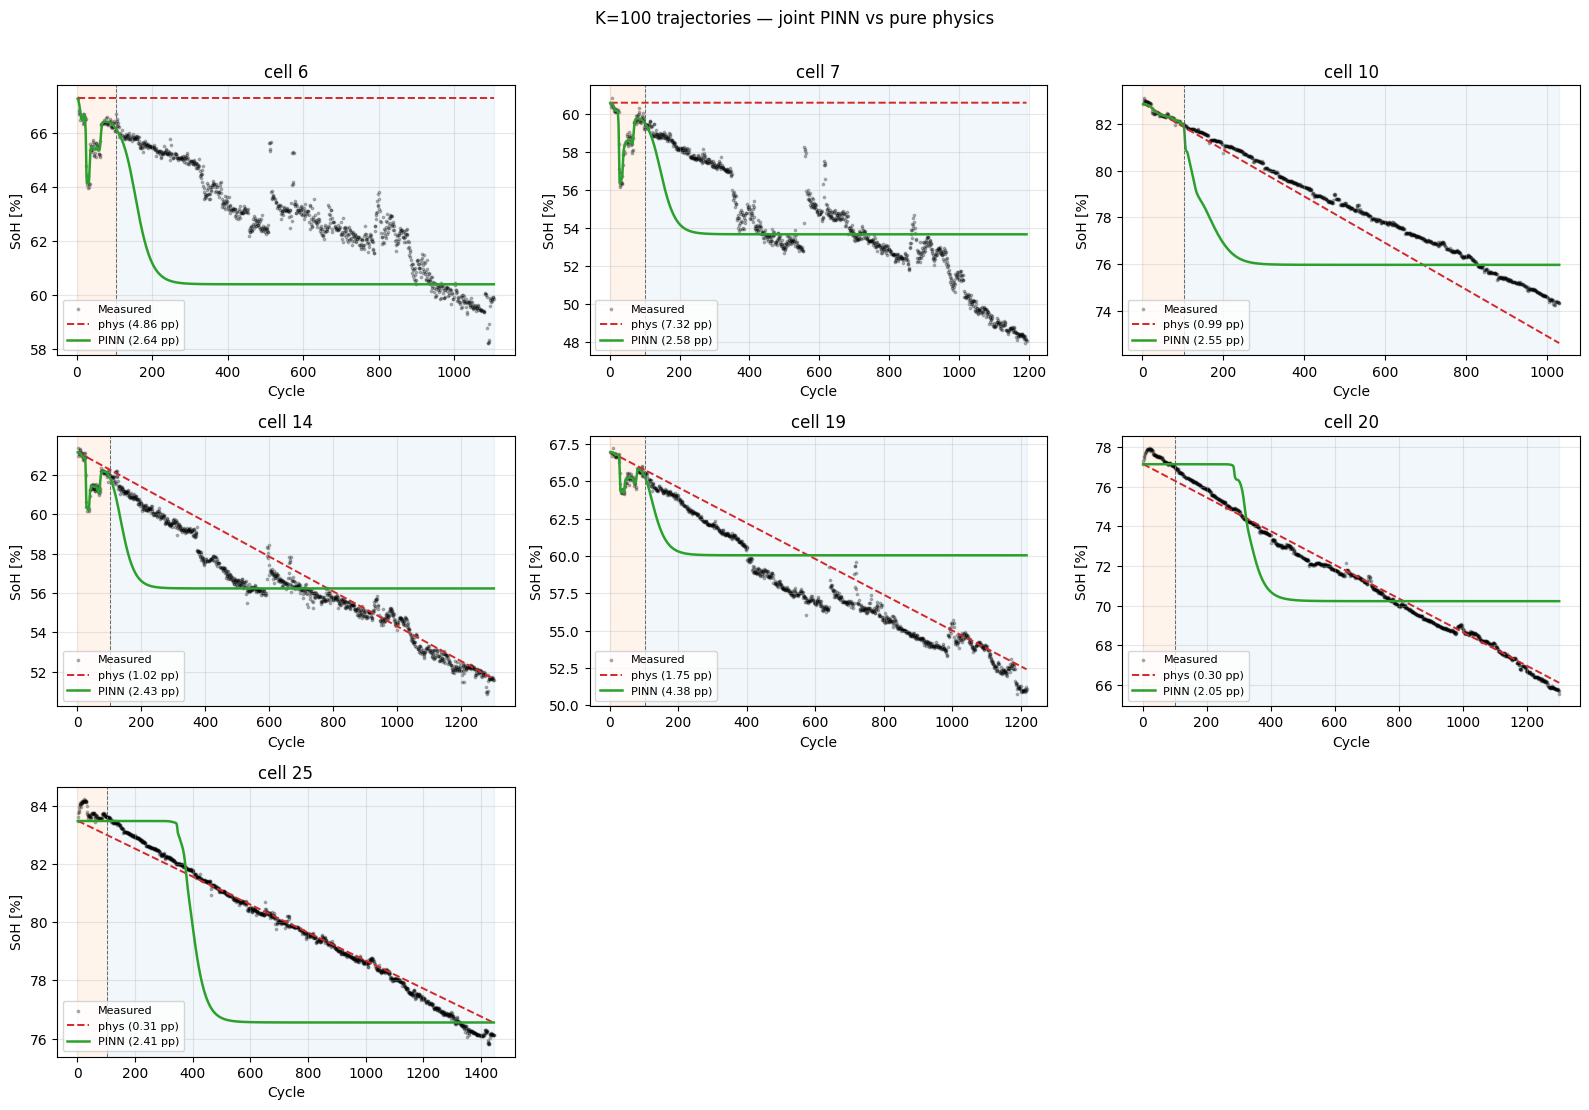

In [5]:
K_show = 100
cells_k100 = sorted([cid for (K, cid) in trajectories.keys() if K == K_show])
fig, axs = plt.subplots(3, 3, figsize=(16, 11))
axs = axs.flatten()
for ax, cid in zip(axs, cells_k100):
    n, s, soh_pred, soh_phys, first_cy, k_end = trajectories[(K_show, cid)]
    r = df[(df.K_train_cy == K_show) & (df.cell_id == cid)].iloc[0]
    ax.axvspan(k_end, n[-1], color='tab:blue', alpha=0.06)
    ax.axvspan(first_cy, k_end, color='tab:orange', alpha=0.08)
    ax.scatter(n, s*100, s=3, color='black', alpha=0.25, label='Measured')
    ax.plot(n, soh_phys*100, color='tab:red', lw=1.4, ls='--',
            label=f"phys ({r['rmse_phys_test_pp']:.2f} pp)")
    ax.plot(n, soh_pred*100, color='tab:green', lw=1.8,
            label=f"PINN ({r['rmse_pinn_test_pp']:.2f} pp)")
    ax.axvline(k_end, color='dimgray', ls='--', lw=0.7)
    ax.set_title(f'cell {cid}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SoH [%]')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower left')
for ax in axs[len(cells_k100):]:
    ax.set_visible(False)
fig.suptitle(f'K={K_show} trajectories — joint PINN vs pure physics', y=1.005)
fig.tight_layout()
plt.show()

## 5. Trajectory grid at K=50 — where PINN wins biggest

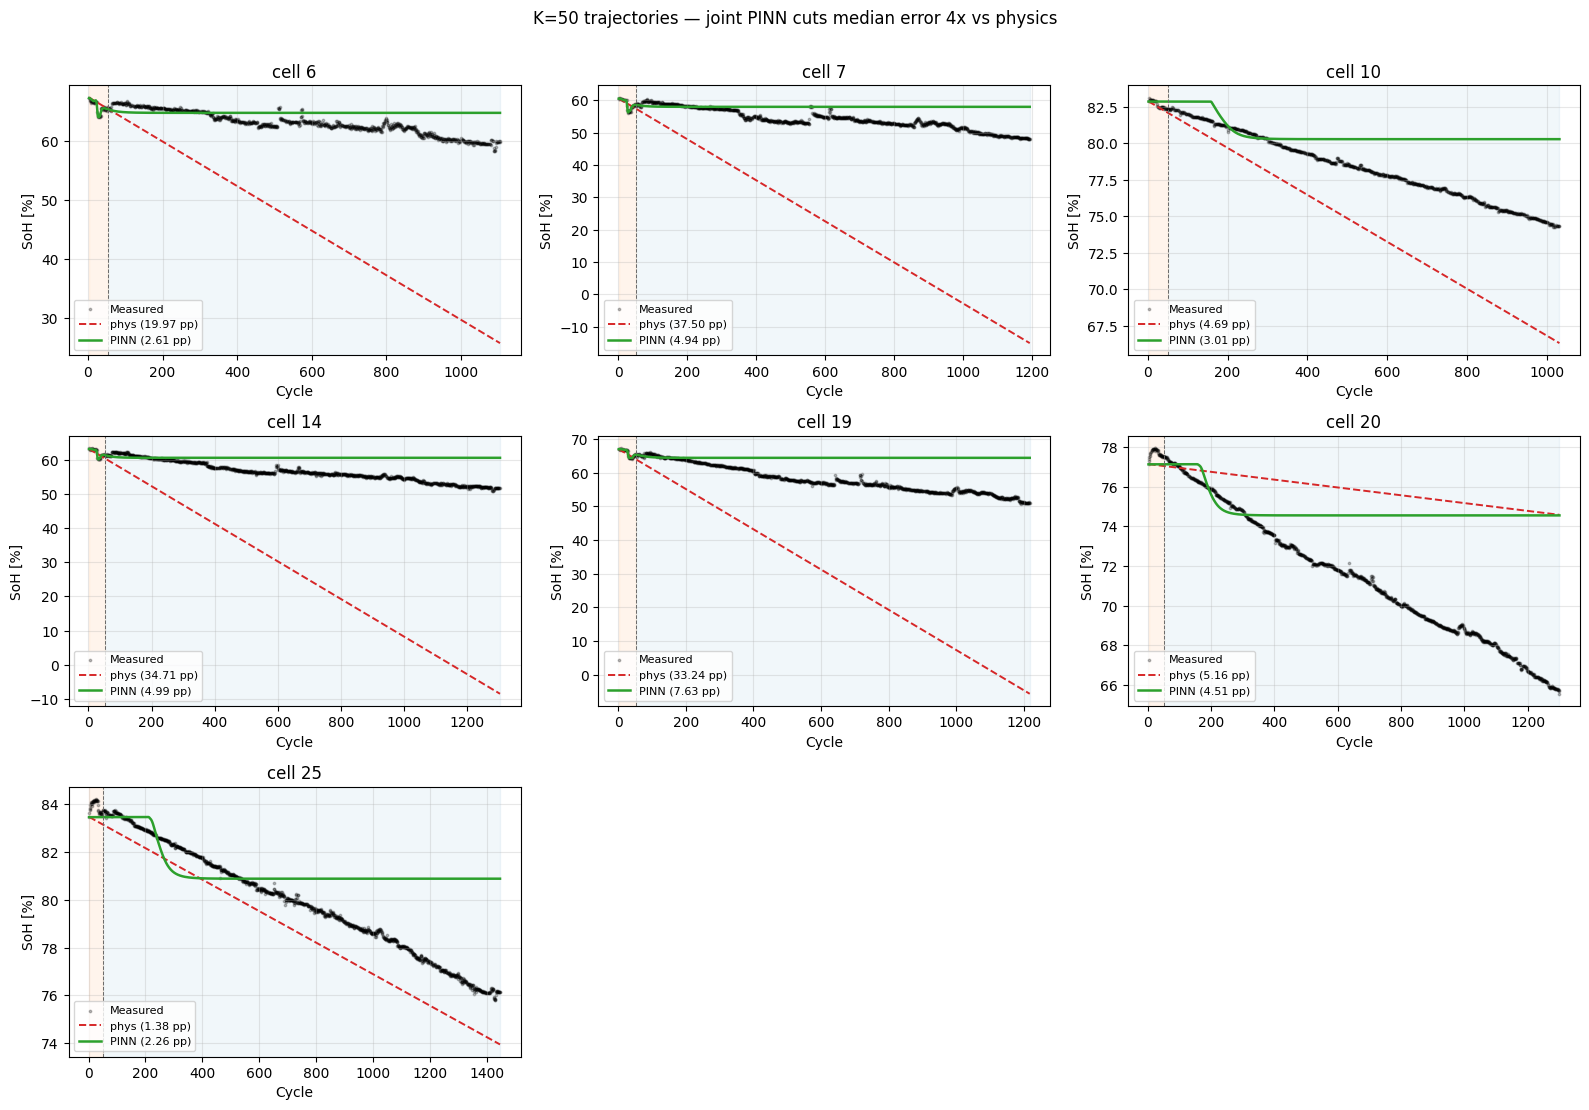

In [6]:
K_show = 50
cells_k50 = sorted([cid for (K, cid) in trajectories.keys() if K == K_show])
fig, axs = plt.subplots(3, 3, figsize=(16, 11))
axs = axs.flatten()
for ax, cid in zip(axs, cells_k50):
    n, s, soh_pred, soh_phys, first_cy, k_end = trajectories[(K_show, cid)]
    r = df[(df.K_train_cy == K_show) & (df.cell_id == cid)].iloc[0]
    ax.axvspan(k_end, n[-1], color='tab:blue', alpha=0.06)
    ax.axvspan(first_cy, k_end, color='tab:orange', alpha=0.08)
    ax.scatter(n, s*100, s=3, color='black', alpha=0.25, label='Measured')
    ax.plot(n, soh_phys*100, color='tab:red', lw=1.4, ls='--',
            label=f"phys ({r['rmse_phys_test_pp']:.2f} pp)")
    ax.plot(n, soh_pred*100, color='tab:green', lw=1.8,
            label=f"PINN ({r['rmse_pinn_test_pp']:.2f} pp)")
    ax.axvline(k_end, color='dimgray', ls='--', lw=0.7)
    ax.set_title(f'cell {cid}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SoH [%]')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower left')
for ax in axs[len(cells_k50):]:
    ax.set_visible(False)
fig.suptitle(f'K={K_show} trajectories — joint PINN cuts median error 4x vs physics', y=1.005)
fig.tight_layout()
plt.show()

## 6. Reading the results — what story do we have?

| K | PINN median | phys median | PINN cells <3pp | phys cells <3pp | Comment |
|---|---|---|---|---|---|
| 50 | 4.5 pp | **20.0 pp** | 2/7 | 1/7 | PINN cuts median 4× but doesn't cross target |
| **100** | **2.5 pp** | 1.0 pp | **6/7** | 5/7 | Sweet spot — PINN adds 1 cell (cell 6) |
| 200 | 2.9 pp | 1.6 pp | 4/7 | 5/7 | PINN regresses |
| 400 | 5.2 pp | 1.4 pp | 1/7 | **7/7** | PINN badly regresses — likely training/scheduler issue |

### Current headline candidates

**Path A (K=100):** *Joint PINN reaches 6/7 cells under 3 pp at K=100 — matches pure physics coverage at K=200. Small win.*

**Path B (K=50):** *Joint PINN cuts median held-out RMSE 4× vs pure physics at K=50. But only 2/7 cells cross the 3 pp target.*

### Why K=400 regresses

This is a bug, not physics — the training loop uses fewer epochs (4000) at K=400 than at K=100 (6000), assuming more data → faster convergence. It's the opposite: more training data + physics collocation × 200 pts × 7 cells creates a bigger optimisation problem. Fix: increase epochs at higher K, or use adaptive early stopping.